## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from time import time
from collections import Counter
from pathlib import Path
import pandas as pd
import numpy as np
from numpy.linalg import norm
from scipy.spatial.distance import cdist, cosine

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from gensim.models import Word2Vec, KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

from sklearn.decomposition import IncrementalPCA

print("Import done!")

Import done!


In [4]:
sns.set_style('white')

In [6]:
analogies_path = Path('data', 'analogies-en.txt')
print(analogies_path)

data\analogies-en.txt


## About the Original Jensen Notebook

This notebook is based on the excellent material provided by **Stefan Jansen** in the GitHub repository accompanying his book *Machine Learning for Algorithmic Trading*. In particular, it revisits the word-embedding workflow from the chapter on word embeddings for earnings calls and SEC filings, where pre-trained vectors are loaded, evaluated through analogy tasks, and visualized in a lower-dimensional space. Jansen’s repository remains a very valuable educational resource because it connects natural language processing techniques with practical applications in financial machine learning. [See here for the git hub repository](https://github.com/stefan-jansen/machine-learning-for-trading/tree/main).

The version available in the original repository, however, was written for older versions of the Python scientific stack. As a consequence, some parts of the notebook no longer run unchanged with recent versions of libraries such as **Gensim** and **pandas**. For example, Gensim 4 introduced several API changes, replacing older attributes and methods such as `index2word` with `index_to_key`, while pandas deprecated and later removed the `DataFrame.append()` method in favor of `pd.concat()`.

The present notebook should therefore be understood as a revised and updated version of Jansen’s original workflow. The conceptual structure remains the same, but the code has been adapted to work with current library versions and to make the main steps more explicit, robust, and reproducible.

## A Short Introduction to Gensim

In this notebook we use **Gensim**, a Python library designed for working with semantic vector representations of text. Gensim is widely used in natural language processing because it provides efficient tools for training, loading, storing, and querying word embeddings and other vector-space models.

Our goal in this notebook is not to train a new embedding model from scratch, but to work with **pre-trained word vectors** such as GloVe embeddings. For this reason, we mainly use Gensim’s `KeyedVectors` class, which stores a mapping from words to numerical vectors. Each word is associated with a dense vector representation, and words that occur in similar linguistic contexts tend to have vectors that are close to each other in the embedding space.

Gensim is useful here for three main reasons. First, it can load large pre-trained embedding files in word2vec-compatible format. Second, it provides convenient access to the vocabulary, the vector matrix, and word-to-index mappings. Third, it includes built-in tools for evaluating embeddings on word analogy tasks, such as:

$$
\text{king} : \text{queen} :: \text{man} : \text{woman}
$$

In the notebook, we use Gensim to load the pre-trained vectors, evaluate their performance on analogy questions, extract the vector matrix, normalize the embeddings, and finally visualize selected analogy relationships after reducing the vectors to two dimensions with PCA.

## A Short Introduction to Pre-trained GloVe Vectors

In this notebook we use **pre-trained GloVe vectors** as examples of classical static word embeddings. GloVe stands for **Global Vectors for Word Representation** and was introduced by Jeffrey Pennington, Richard Socher, and Christopher Manning at Stanford University in 2014. The central idea is to represent each word as a dense numerical vector learned from large-scale word co-occurrence statistics. Words that tend to appear in similar contexts are assigned vectors that are close to each other in the embedding space. 

GloVe differs from purely local prediction-based models such as word2vec because it is explicitly trained on **global word-word co-occurrence counts** collected from a large corpus. In simplified terms, the model tries to learn vectors whose geometric relationships reflect how often words occur together across the entire training corpus. This is why GloVe vectors often display meaningful linear regularities. The GloVe project provides several sets of pre-trained vectors, trained on different corpora such as Wikipedia, Gigaword, Twitter, and Common Crawl. These files contain a vocabulary of words, each associated with a vector of fixed dimension, for example 50, 100, 200, or 300 dimensions depending on the chosen model. In this notebook, we load these pre-trained vectors instead of training embeddings from scratch, which allows us to focus on their semantic structure, their analogy performance, and their visualization in a lower-dimensional space.

It is important to remember that GloVe vectors are **static embeddings**. This means that each word has a single vector representation, independently of the sentence in which it appears. For example, the word *bank* receives one vector whether it refers to a financial institution or the side of a river. This is different from modern contextual embeddings used in Transformer-based models, where the representation of a word depends on its surrounding context. Nevertheless, GloVe remains pedagogically valuable because it offers a clear and interpretable way to study the geometry of word meanings, semantic similarity, and analogy relationships.

## Convert GloVE Vectors to gensim format

### Why We Convert GloVe Files into word2vec Format

The pre-trained GloVe vectors are distributed as plain text files. Each line contains a word followed by its numerical vector representation. For example, in simplified form:

```text
king 0.123 -0.084 0.532 ...
queen 0.221 0.017 0.418 ...
man 0.091 -0.140 0.302 ...
````

This is very similar to the text format used by word2vec. The important practical difference is that a standard word2vec text file usually begins with a header line containing two numbers:

```text
vocabulary_size vector_dimension
```

For example:

```text
400000 300
king 0.123 -0.084 0.532 ...
queen 0.221 0.017 0.418 ...
man 0.091 -0.140 0.302 ...
```

The first number tells the loader how many word vectors are contained in the file. The second number tells it the dimensionality of each vector. A GloVe file usually does not contain this initial header line. It starts directly with the first word and its vector. Gensim’s documentation describes the two text formats as almost identical, except that the word2vec format includes the number of vectors and their dimension at the beginning of the file. ([PII Tools][1])

This is why older Gensim workflows often converted GloVe files into word2vec format before loading them. The conversion simply adds the missing header line; it does not change the vectors themselves, the vocabulary, or the mathematical meaning of the embeddings. After conversion, the file becomes easier to load with:

```python
KeyedVectors.load_word2vec_format(...)
```

In recent versions of Gensim, explicit conversion is not always necessary. The function `load_word2vec_format` has a `no_header=True` option, which tells Gensim that the file has no initial `vocabulary_size vector_dimension` line and therefore should be treated like a GloVe-style text file. Gensim’s current documentation explains that `no_header=False` expects a standard word2vec file with a first-line declaration, while `no_header=True` assumes the file starts directly with the first vector. ([PII Tools][2])

Therefore, there are two possible approaches:

```python
# Option 1: load a raw GloVe file directly
model = KeyedVectors.load_word2vec_format(
    glove_file,
    binary=False,
    no_header=True
)
```

or:

```python
# Option 2: load a previously converted word2vec-style file
model = KeyedVectors.load_word2vec_format(
    word2vec_file,
    binary=False
)
```

In this notebook, we use the word2vec-compatible format because it makes the loading process explicit and consistent with the Gensim `KeyedVectors` workflow. The conversion is only a formatting step: the semantic information contained in the GloVe vectors remains unchanged.


[1]: https://radimrehurek.com/gensim/scripts/glove2word2vec.html?utm_source=chatgpt.com "scripts.glove2word2vec – Convert glove format to word2vec"
[2]: https://radimrehurek.com/gensim/models/keyedvectors.html?utm_source=chatgpt.com "models.keyedvectors – Store and query word vectors"


The various GloVE vectors are available [here](https://nlp.stanford.edu/projects/glove/). Download link for the [wikipedia](http://nlp.stanford.edu/data/glove.6B.zip) version. Unzip and store in `data/glove`.

In [7]:
glove_path = Path('c:/', 'data','sandbox', 'glove')
print(glove_path)

c:\data\sandbox\glove


### WikiPedia

In [8]:
glove_wiki_file= glove_path / 'glove.6B.300d.txt'
word2vec_wiki_file = glove_path / 'glove.wiki.gensim.txt'

In [9]:
glove2word2vec(glove_input_file=glove_wiki_file, word2vec_output_file=word2vec_wiki_file)
print("Done!")

Done!


### Twitter Data

In [10]:
glove_twitter_file= glove_path / 'glove.twitter.27B.200d.txt'
word2vec_twitter_file = glove_path / 'glove.twitter.gensim.txt'

In [11]:
glove2word2vec(glove_input_file=glove_twitter_file, word2vec_output_file=word2vec_twitter_file)
print("Done!")

Done!


### Common Crawl

In [12]:
glove_crawl_file= glove_path / 'glove.840B.300d.txt'
word2vec_crawl_file = glove_path / 'glove.crawl.gensim.txt'

In [13]:
glove2word2vec(glove_input_file=glove_crawl_file, word2vec_output_file=word2vec_crawl_file)
print("Done!")

Done!


## Inspecting a Word Vector File Before Loading It

Before loading large pre-trained embedding files with Gensim, it is useful to inspect their structure directly. Word vector files can be very large, often several gigabytes, and small formatting problems can lead to confusing errors during loading. For example, a file may be in raw GloVe format rather than word2vec format, the header may declare the wrong number of vectors, or some lines may not contain the expected number of numerical values.

The following utility function performs a preliminary diagnostic check on a word vector file. It verifies whether the file exists, reports its size, reads the first line, and checks whether that line looks like a standard word2vec header. In the word2vec text format, the first line should contain two integers: the vocabulary size and the vector dimension. For example:

```text
2196017 300
````

This means that the file is expected to contain 2,196,017 word vectors, each represented by a 300-dimensional numerical vector.

If the header is present, the function compares the expected number of vectors with the actual number of data lines in the file. It also checks whether each line contains the expected number of elements: one token plus the numerical components of the vector. For a 300-dimensional embedding, each valid line should therefore contain 301 elements.

This inspection routine is especially useful because it allows us to identify file-format problems before calling `KeyedVectors.load_word2vec_format()`. Without such a check, Gensim may raise errors such as an unexpected end of file, a wrong vector size, or a parsing error, but the source of the problem may not be immediately clear. By inspecting the file first, we can understand whether the issue is due to a missing header, a corrupted or incomplete file, an incorrect conversion from GloVe to word2vec format, or unusual tokens inside the vocabulary.

In this notebook, this routine is helpful because we work with large pre-trained GloVe embeddings that have been converted into word2vec-compatible format. Since these files are large and expensive to reload repeatedly, a simple diagnostic function helps us make the workflow more robust and easier to debug.

One small caveat: the check for `bad_lines` is useful as a warning, but it should not always be interpreted as definitive proof that the file is invalid. Some GloVe tokens may contain unusual whitespace characters, such as non-breaking spaces. A simple `split()` may treat those characters as separators, while Gensim may still be able to read the line correctly. So the function is best understood as a **diagnostic tool**, not as a strict validator.

In [14]:
from pathlib import Path


def inspect_word_vector_file(path, n_preview=3):
    """
    Inspect the structure of a word-vector file before loading it with Gensim.

    This function is especially useful when working with large pre-trained
    embedding files such as GloVe or word2vec vectors.

    It checks:
    - whether the file exists;
    - the file size;
    - whether the first line looks like a word2vec-style header;
    - the expected vocabulary size;
    - the expected vector dimensionality;
    - the actual number of vector lines in the file;
    - whether some lines have an unexpected number of fields.

    Parameters
    ----------
    path : str or pathlib.Path
        Path to the word-vector file to inspect.

    n_preview : int, default=3
        Number of initial data lines to print as a preview.
    """

    # Convert the input path to a pathlib.Path object.
    # This makes path manipulation more convenient and platform-independent.
    path = Path(path)

    # Print basic information about the file.
    print("File:", path)

    # Check whether the file exists at the specified location.
    print("Exists:", path.exists())

    # Print the file size in megabytes.
    # This is useful because pre-trained embedding files can be several GB large.
    print("Size MB:", path.stat().st_size / 1024**2)

    # Open the file in text mode.
    #
    # encoding="utf-8":
    #     Most word-vector text files are UTF-8 encoded.
    #
    # errors="replace":
    #     If the file contains invalid UTF-8 characters, Python will not crash.
    #     Instead, invalid characters will be replaced by a special placeholder.
    with path.open("r", encoding="utf-8", errors="replace") as f:

        # Read the first line of the file.
        # In word2vec text format, this line should usually contain:
        #
        #     vocabulary_size vector_dimension
        #
        # For example:
        #
        #     2196017 300
        #
        first_line = f.readline().strip()

        print("\nFirst line:")

        # Print only the first 300 characters of the first line.
        # This prevents excessive output if the file has no header and the
        # first line is already a full word vector.
        print(first_line[:300])

        # Split the first line into separate fields.
        # If the file is in word2vec format, we expect exactly two fields:
        # the vocabulary size and the vector dimension.
        parts = first_line.split()

        # Check whether the first line looks like a word2vec header.
        #
        # A valid header should contain:
        # - exactly two fields;
        # - both fields should be integers.
        has_header = (
            len(parts) == 2
            and parts[0].isdigit()
            and parts[1].isdigit()
        )

        print("\nLooks like word2vec header:", has_header)

        # If the file appears to have a word2vec-style header,
        # we can perform deeper checks.
        if has_header:

            # The first number in the header is the expected vocabulary size,
            # that is, the number of word vectors declared by the file.
            expected_vocab = int(parts[0])

            # The second number is the expected dimensionality of each vector.
            expected_dim = int(parts[1])

            print("Expected vocabulary size:", expected_vocab)
            print("Expected vector size:", expected_dim)

            # Counter for the actual number of data lines found after the header.
            data_lines = 0

            # List used to store suspicious lines.
            #
            # A line is considered suspicious if it does not contain:
            #
            #     1 word token + expected_dim numerical values
            #
            # For example, with 300-dimensional vectors, a normal line should
            # contain 301 fields.
            bad_lines = []

            # Start reading the rest of the file.
            #
            # We start line numbering from 2 because line 1 is the header.
            for i, line in enumerate(f, start=2):

                # Count one more data line.
                data_lines += 1

                # Remove trailing whitespace and split the line into fields.
                #
                # Usually the first field is the word and the remaining fields
                # are the vector components.
                values = line.rstrip().split()

                # Check whether the line has the expected number of fields.
                #
                # For a vector of dimension D, the line should contain:
                #
                #     word + D vector components
                #
                # Therefore the expected number of fields is D + 1.
                if len(values) != expected_dim + 1:

                    # Store:
                    # - the line number;
                    # - the number of fields actually found;
                    # - a short preview of the suspicious line.
                    bad_lines.append((i, len(values), line[:120]))

                # Print a preview of the first few vector lines.
                #
                # This helps us visually inspect whether the file looks normal.
                if data_lines <= n_preview:
                    print(f"\nPreview data line {i}:")
                    print(line[:300])

            # After reading the file, print the actual number of vector lines.
            print("\nActual data lines:", data_lines)

            # Compare the number declared in the header with the number
            # of lines actually found in the file.
            #
            # If they differ, Gensim may raise an EOFError or another loading
            # error, because it expects the number of vectors declared in the
            # header to match the file content.
            if data_lines != expected_vocab:
                print("\nWARNING: header and actual number of vectors do not match.")
                print("Header says:", expected_vocab)
                print("Actual lines:", data_lines)

            # If suspicious lines were found, print the first few examples.
            #
            # This is useful for diagnosing formatting problems, corrupted lines,
            # unusual tokens, or incorrect conversions from GloVe to word2vec.
            if bad_lines:
                print("\nBad lines found:")

                # Print only the first 10 suspicious lines to avoid flooding
                # the notebook output.
                for item in bad_lines[:10]:
                    print(item)

        # If the first line does not look like a word2vec header,
        # the file may be a raw GloVe file.
        #
        # Raw GloVe files usually start immediately with:
        #
        #     word value_1 value_2 value_3 ...
        #
        # and do not include the initial:
        #
        #     vocabulary_size vector_dimension
        #
        # line.
        else:
            print("\nThis does not look like a word2vec file with header.")
            print("It may be a raw GloVe file.")

In [15]:
inspect_word_vector_file(word2vec_crawl_file)
print("Done!")

File: c:\data\sandbox\glove\glove.crawl.gensim.txt
Exists: True
Size MB: 5384.679177284241

First line:
2196017 300

Looks like word2vec header: True
Expected vocabulary size: 2196017
Expected vector size: 300

Preview data line 2:
, -0.082752 0.67204 -0.14987 -0.064983 0.056491 0.40228 0.0027747 -0.3311 -0.30691 2.0817 0.031819 0.013643 0.30265 0.0071297 -0.5819 -0.2774 -0.062254 1.1451 -0.24232 0.1235 -0.12243 0.33152 -0.006162 -0.30541 -0.13057 -0.054601 0.037083 -0.070552 0.5893 -0.30385 0.2898 -0.14653 -0.27052 0.37161 0.

Preview data line 3:
. 0.012001 0.20751 -0.12578 -0.59325 0.12525 0.15975 0.13748 -0.33157 -0.13694 1.7893 -0.47094 0.70434 0.26673 -0.089961 -0.18168 0.067226 0.053347 1.5595 -0.2541 0.038413 -0.01409 0.056774 0.023434 0.024042 0.31703 0.19025 -0.37505 0.035603 0.1181 0.012032 -0.037566 -0.5046 -0.049261 0.092351 0.110

Preview data line 4:
the 0.27204 -0.06203 -0.1884 0.023225 -0.018158 0.0067192 -0.13877 0.17708 0.17709 2.5882 -0.35179 -0.17312 0.43285 -0.107

## Evaluate Embeddings

After loading the pre-trained word vectors, the next step is to evaluate whether they capture meaningful semantic and syntactic relationships between words. Word embeddings are useful only if their geometry reflects some structure of language: words with related meanings should be close to each other, and certain relationships between words should correspond to consistent directions in the vector space.

A classical way to evaluate word embeddings is through **word analogy tasks**. In these tasks, the model is asked to solve questions of the form:

$$
a : b :: c : d
$$

meaning: “\(a\) is to \(b\) as \(c\) is to which word?” For example:

$$
\text{king} : \text{queen} :: \text{man} : ?
$$

A good embedding model should return a word close to *woman*. This can be tested geometrically by checking whether the vector operation:

$$
\mathbf{v}_{queen} - \mathbf{v}_{king} + \mathbf{v}_{man}
$$

points close to the vector representing *woman*.

In this section, we use Gensim’s analogy evaluation tools to measure how well the pre-trained GloVe vectors solve different categories of analogy questions. These categories include both semantic relationships, such as capital cities and countries, and syntactic relationships, such as grammatical transformations. The resulting accuracy gives us a simple but informative way to compare different sets of pre-trained embeddings.

### The Gensim tool used for analogy evaluation

To evaluate the embeddings, we use the Gensim method:

```python
model.evaluate_word_analogies(...)
````

This method is available for `KeyedVectors` objects, which are the Gensim data structures used to store and query pre-trained word vectors. The function takes as input a text file containing analogy questions, usually organized into thematic sections such as capital cities, family relations, or grammatical transformations.

For each analogy question of the form:

$$
a : b :: c : d
$$

Gensim checks whether the embedding model can recover the expected word (d) by using vector arithmetic. Internally, it compares the resulting vector with the vectors in the vocabulary and verifies whether the correct answer is retrieved. The method returns two outputs: an overall accuracy score and a detailed list of results for each section, including the correctly and incorrectly solved analogies.

In this notebook, we use this tool to compare the performance of different pre-trained GloVe embeddings and to identify which types of semantic or syntactic relationships are better captured by each embedding space.

In [26]:
results_path = Path('c:/', 'data','sandbox', 'results', 'glove')
print(results_path)

c:\data\sandbox\results\glove


In [17]:
from gensim.models import KeyedVectors
import pandas as pd
import numpy as np

def eval_analogies(file_name, analogies_path, vocab=30000, binary=False):
    model = KeyedVectors.load_word2vec_format(
        file_name,
        binary=binary,
        limit=vocab
    )

    overall_score, sections = model.evaluate_word_analogies(
        analogies_path,
        restrict_vocab=vocab,
        case_insensitive=True
    )

    result = (
        pd.DataFrame(
            [
                [
                    c["section"],
                    len(c["correct"]),
                    len(c["incorrect"])
                ]
                for c in sections
            ],
            columns=["category", "correct", "incorrect"]
        )
        .assign(samples=lambda x: x["correct"] + x["incorrect"])
        .assign(
            average=lambda x: np.where(
                x["samples"] > 0,
                x["correct"] / x["samples"],
                np.nan
            )
        )
        .drop(["correct", "incorrect"], axis=1)
    )

    return result

### twitter result

In [18]:
twitter_result = eval_analogies(word2vec_twitter_file, analogies_path, vocab=100000, binary=False)
twitter_result.to_csv(glove_path / 'accuracy_twitter.csv', index=False)
twitter_result

,category,samples,average
0,capital-common-countries,462,0.701299
1,capital-world,930,0.690323
2,city-in-state,3644,0.350714
3,currency,268,0.018657
4,family,342,0.824561
5,gram1-adjective-to-adverb,650,0.143077
6,gram2-opposite,342,0.365497
7,gram3-comparative,1260,0.757937
8,gram4-superlative,930,0.686022
9,gram5-present-participle,702,0.750712


### wiki result

In [19]:
wiki_result = eval_analogies(word2vec_wiki_file, analogies_path, vocab=100000, binary=False)
wiki_result.to_csv(glove_path / 'accuracy_wiki.csv', index=False)
wiki_result

,category,samples,average
0,capital-common-countries,506,0.948617
1,capital-world,8372,0.964644
2,city-in-state,4242,0.599953
3,currency,752,0.174202
4,family,506,0.881423
5,gram1-adjective-to-adverb,992,0.225806
6,gram2-opposite,756,0.285714
7,gram3-comparative,1332,0.882132
8,gram4-superlative,1056,0.746212
9,gram5-present-participle,1056,0.699811


### Common Crawl result

In [20]:
crawl_result = eval_analogies(word2vec_crawl_file, analogies_path, vocab=100000, binary=False)
crawl_result.to_csv(glove_path / 'accuracy_crawl.csv', index=False)
crawl_result

,category,samples,average
0,capital-common-countries,506,0.946640
1,capital-world,4290,0.917483
2,city-in-state,4242,0.706742
3,currency,206,0.184466
4,family,420,0.978571
5,gram1-adjective-to-adverb,992,0.388105
6,gram2-opposite,702,0.361823
7,gram3-comparative,1332,0.876877
8,gram4-superlative,1122,0.919786
9,gram5-present-participle,1056,0.827652


### Combine & compare results

In [27]:
cat_dict = {'capital-common-countries':'Capitals',
            'capital-world':'Capitals RoW',
            'city-in-state':'City-State',
            'currency':'Currency',
            'family':'Famliy',
            'gram1-adjective-to-adverb':'Adj-Adverb',
            'gram2-opposite':'Opposite',
            'gram3-comparative':'Comparative',
            'gram4-superlative':'Superlative',
            'gram5-present-participle':'Pres. Part.',
            'gram6-nationality-adjective':'Nationality',
            'gram7-past-tense':'Past Tense',
            'gram8-plural':'Plural',
            'gram9-plural-verbs':'Plural Verbs',
            'total':'Total'}

In [28]:
accuracy = pd.concat(
    [
        twitter_result.assign(glove="Twitter"),
        wiki_result.assign(glove="Wiki"),
        crawl_result.assign(glove="Crawl")
    ],
    axis=0,
    ignore_index=True
)

In [29]:
accuracy.category = accuracy.category.replace(cat_dict)
accuracy = accuracy.rename(columns=str.capitalize)

In [30]:
accuracy.to_csv(results_path / 'accuracy.csv', index=False)

In [31]:
accuracy = pd.read_csv(results_path / 'accuracy.csv')

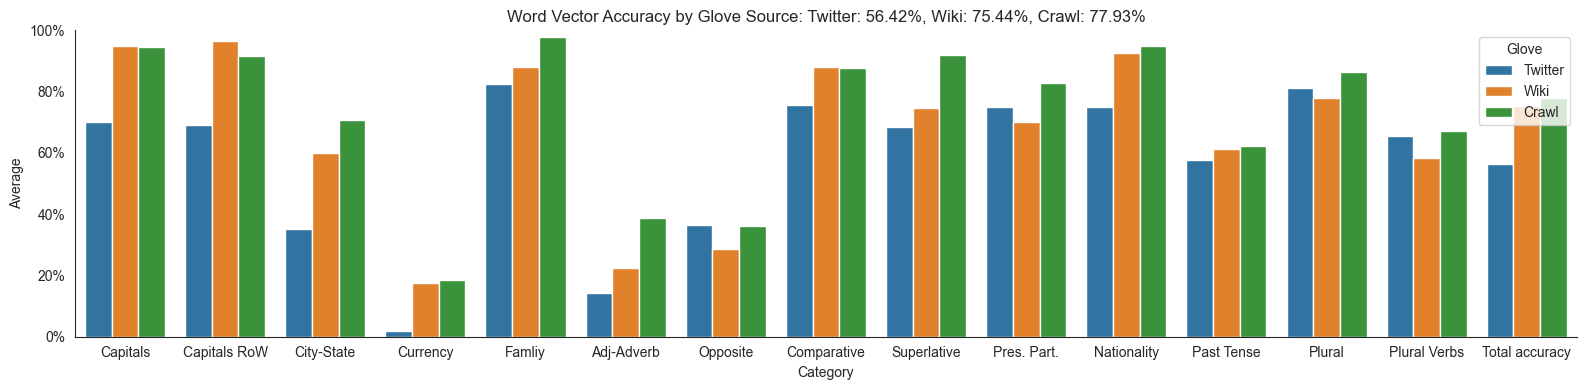

In [32]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(x='Category', y='Average', hue='Glove', data=accuracy, ax=ax)
ax.set_title(f'Word Vector Accuracy by Glove Source: Twitter: {0.564228:.2%}, Wiki: {0.75444:.2%}, Crawl: {0.779347:.2%}')
ax.set_ylim(0,1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
fig.tight_layout()
fig.savefig(results_path / 'glove_accuracy', dpi=300);

## Visualize Embeddings

### Load GloVe Wiki Vectors

In [33]:
from gensim.models import KeyedVectors
from sklearn.decomposition import IncrementalPCA
from numpy.linalg import norm
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the embedding model
# ------------------------------------------------------------

vocab_size = 100000

model = KeyedVectors.load_word2vec_format(
    word2vec_wiki_file,
    binary=False,
    limit=vocab_size
)
print("Model loaded!")

Model loaded!


In [34]:
# ------------------------------------------------------------
# 2. Evaluate analogies
# ------------------------------------------------------------

overall_score, sections = model.evaluate_word_analogies(
    str(analogies_path),
    restrict_vocab=vocab_size,
    case_insensitive=True
)

print("Overall analogy score:", overall_score)

Overall analogy score: 0.7544449783757808


In [35]:
# ------------------------------------------------------------
# 3. Extract and normalize vectors
# ------------------------------------------------------------

vectors = model.vectors.copy()

vector_norms = norm(vectors, axis=1, keepdims=True)
vectors = vectors / vector_norms

print("Vector matrix shape:", vectors.shape)

Vector matrix shape: (100000, 300)


In [36]:
# ------------------------------------------------------------
# 4. Build word-to-id mapping
# ------------------------------------------------------------

words = model.index_to_key
word2id = {word: i for i, word in enumerate(words)}

### Project Embedding into 2D

In [37]:
# ------------------------------------------------------------
# 5. PCA projection
# ------------------------------------------------------------

pca = IncrementalPCA(n_components=2)

vectors2D = pca.fit_transform(vectors)

explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=["PC1", "PC2"]
).mul(100)

print(explained_variance)

PC1    2.604632
PC2    1.293812
dtype: float64


### Plot Analogy Examples

In [38]:
# ------------------------------------------------------------
# 6. Collect correct analogy results
# ------------------------------------------------------------

results_list = []
correct = 0
incorrect = 0

for section in sections:
    # Gensim usually appends an aggregate "Total accuracy" section.
    # We skip it to avoid double-counting examples.
    if section["section"].lower().startswith("total"):
        continue

    correct += len(section["correct"])
    incorrect += len(section["incorrect"])

    section_df = pd.DataFrame(
        section["correct"],
        columns=["a", "b", "c", "expected"]
    )

    if not section_df.empty:
        section_df = section_df.apply(lambda col: col.str.lower())

    section_df["section"] = section["section"]

    results_list.append(section_df)

results = pd.concat(results_list, ignore_index=True)

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Computed accuracy:", correct / (correct + incorrect))

results

Correct: 18840
Incorrect: 6132
Computed accuracy: 0.7544449783757808


,a,b,c,expected,section
0,athens,greece,baghdad,iraq,capital-common-countries
1,athens,greece,bangkok,thailand,capital-common-countries
2,athens,greece,beijing,china,capital-common-countries
3,athens,greece,berlin,germany,capital-common-countries
4,athens,greece,bern,switzerland,capital-common-countries
...,...,...,...,...,...
18835,write,writes,speak,speaks,gram9-plural-verbs
18836,write,writes,swim,swims,gram9-plural-verbs
18837,write,writes,think,thinks,gram9-plural-verbs
18838,write,writes,walk,walks,gram9-plural-verbs


In [39]:
from scipy.spatial.distance import cosine
import numpy as np

def find_most_similar_analogy(v):
    """
    Find the analogy whose two displacement vectors are most similar
    after projection into 2D.

    The input v is expected to contain four columns:

        a, b, c, expected

    representing analogies of the form:

        a : b :: c : expected

    Each cell contains the integer index of the corresponding word
    in the embedding vocabulary.
    """

    # Select columns by position, not by column name
    a_idx = v.iloc[:, 0].to_numpy(dtype=int)
    b_idx = v.iloc[:, 1].to_numpy(dtype=int)
    c_idx = v.iloc[:, 2].to_numpy(dtype=int)
    d_idx = v.iloc[:, 3].to_numpy(dtype=int)

    # First analogy displacement: b - a
    v1 = vectors2D[b_idx] - vectors2D[a_idx]

    # Second analogy displacement: expected - c
    v2 = vectors2D[d_idx] - vectors2D[c_idx]

    idx = None
    most_similar = np.inf

    for i in range(len(v1)):
        similarity = cosine(v1[i], v2[i])

        if similarity < most_similar:
            idx = i
            most_similar = similarity

    return idx

In [40]:
def get_plot_lims(coordinates):
    xlim, ylim = coordinates.agg(['min', 'max']).T.values
    xrange, yrange = (xlim[1] - xlim[0]) * .1, (ylim[1] - ylim[0]) * .1
    xlim[0], xlim[1] = xlim[0] - xrange, xlim[1] + xrange
    ylim[0], ylim[1] = ylim[0] - yrange, ylim[1] + yrange
    return xlim, ylim

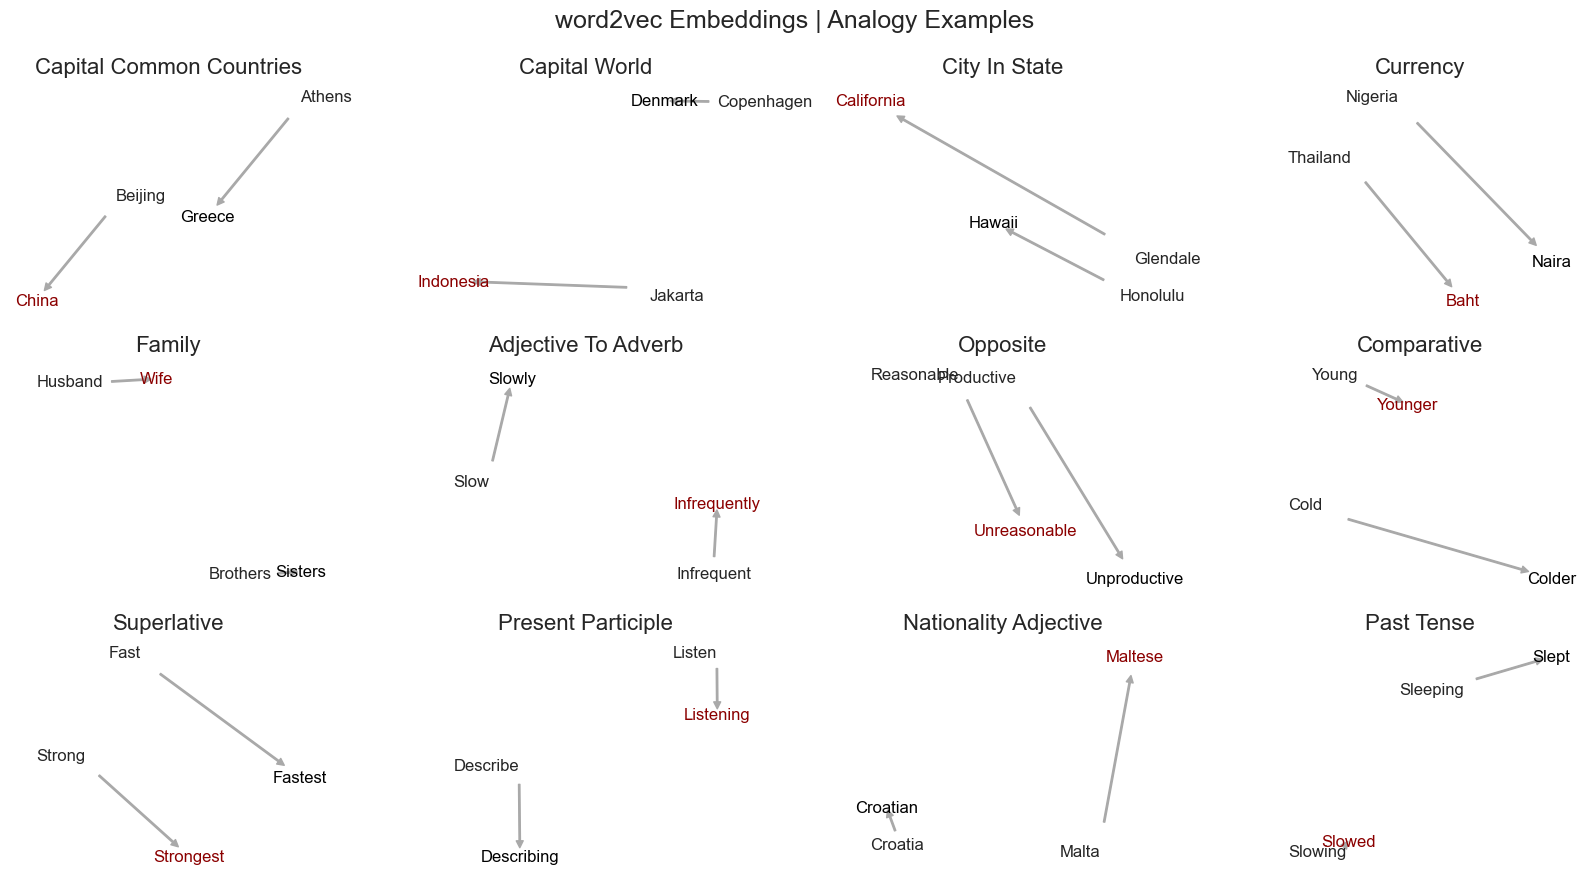

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 9))
axes = axes.flatten()

fc = ec = "darkgrey"

for s, (section, result) in enumerate(results.groupby("section")):
    if s > 11:
        break

    # Convert words into integer ids
    df = (
        result
        .drop("section", axis=1)
        .apply(lambda col: col.map(word2id))
    )

    # Remove rows containing words not found in word2id
    df = df.dropna()

    if df.empty:
        continue

    most_similar_idx = find_most_similar_analogy(df)

    # iloc uses positional indexing, so this is correct
    best_analogy = result.iloc[most_similar_idx, :4].tolist()

    # Use word2id instead of words.index(word), which is much slower
    analogy_idx = [word2id[word] for word in best_analogy]

    best_analogy = [word.capitalize() for word in best_analogy]

    coords = pd.DataFrame(
        vectors2D[analogy_idx],
        columns=["x", "y"]
    )

    xlim, ylim = get_plot_lims(coords)

    axes[s].set_xlim(xlim)
    axes[s].set_ylim(ylim)

    for i in [0, 2]:
        axes[s].annotate(
            best_analogy[i],
            xy=coords.iloc[i + 1],
            xytext=coords.iloc[i],
            arrowprops=dict(
                width=1,
                headwidth=5,
                headlength=5,
                fc=fc,
                ec=ec,
                shrink=0.1
            ),
            fontsize=12
        )

        axes[s].annotate(
            best_analogy[i + 1],
            xy=coords.iloc[i + 1],
            xytext=coords.iloc[i + 1],
            va="center",
            ha="center",
            fontsize=12,
            color="darkred" if i == 2 else "k"
        )

    axes[s].axis("off")

    title = " ".join(
        word.capitalize()
        for word in section.split("-")
        if not word.startswith("gram")
    )

    axes[s].set_title(title, fontsize=16)

fig.suptitle("word2vec Embeddings | Analogy Examples", fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.9)